In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/sudalairajkumar/novel-corona-virus-2019-dataset/covid_19_data.csv')
print(df.head())

   SNo ObservationDate Province/State  Country/Region      Last Update  \
0    1      01/22/2020          Anhui  Mainland China  1/22/2020 17:00   
1    2      01/22/2020        Beijing  Mainland China  1/22/2020 17:00   
2    3      01/22/2020      Chongqing  Mainland China  1/22/2020 17:00   
3    4      01/22/2020         Fujian  Mainland China  1/22/2020 17:00   
4    5      01/22/2020          Gansu  Mainland China  1/22/2020 17:00   

   Confirmed  Deaths  Recovered  
0        1.0     0.0        0.0  
1       14.0     0.0        0.0  
2        6.0     0.0        0.0  
3        1.0     0.0        0.0  
4        0.0     0.0        0.0  


In [2]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(306429, 8)
Index(['SNo', 'ObservationDate', 'Province/State', 'Country/Region',
       'Last Update', 'Confirmed', 'Deaths', 'Recovered'],
      dtype='object')
SNo                    0
ObservationDate        0
Province/State     78103
Country/Region         0
Last Update            0
Confirmed              0
Deaths                 0
Recovered              0
dtype: int64


In [3]:
# The data has one row per province/state per day.
# First add up all provinces for each country on each date,
# then take each country's highest (peak) total.
country_daily = df.groupby(['Country/Region', 'ObservationDate'])[['Confirmed', 'Deaths', 'Recovered']].sum()
country_totals = country_daily.groupby('Country/Region').max()

print("Number of countries/regions:", df['Country/Region'].nunique())
print("\nTop 10 countries by confirmed cases:")
print(country_totals['Confirmed'].nlargest(10))
print("\nTop 10 countries by deaths:")
print(country_totals['Deaths'].nlargest(10))

Number of countries/regions: 229

Top 10 countries by confirmed cases:
Country/Region
US           33251939.0
India        27894800.0
Brazil       16471600.0
France        5978650.0
Turkey        5235978.0
Russia        4995613.0
UK            4496823.0
Italy         4213055.0
Argentina     3732263.0
Germany       3684672.0
Name: Confirmed, dtype: float64

Top 10 countries by deaths:
Country/Region
US          594306.0
Brazil      461057.0
India       325972.0
Mexico      223455.0
UK          128037.0
Italy       126002.0
Russia      118781.0
France      109518.0
Germany      88413.0
Colombia     87747.0
Name: Deaths, dtype: float64


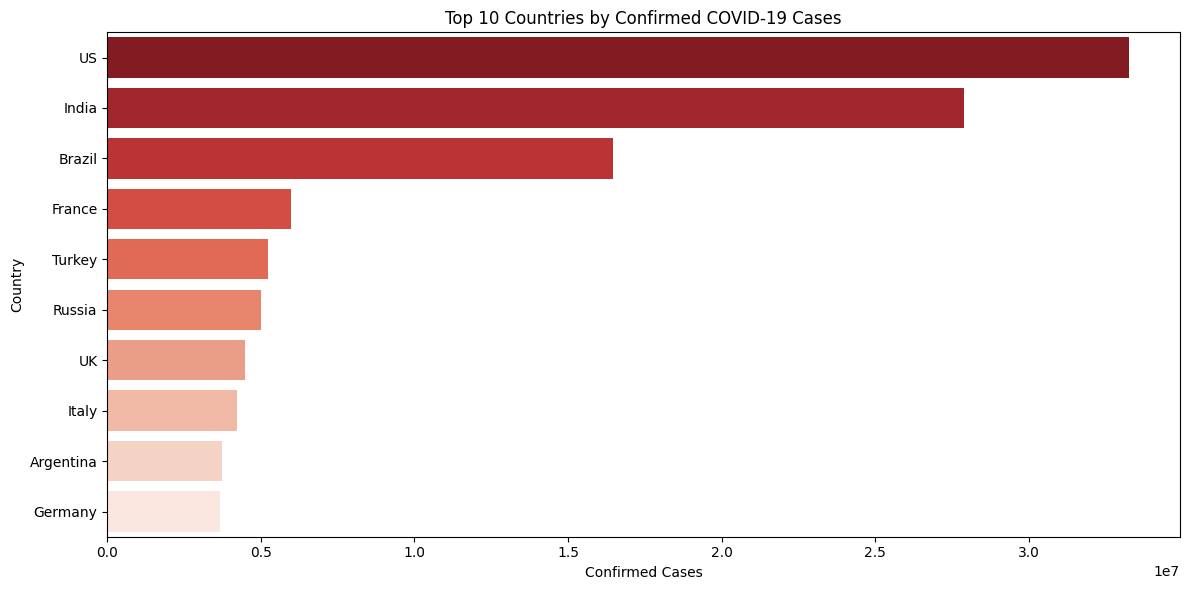

In [4]:
top_countries = country_totals['Confirmed'].nlargest(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, legend=False, palette='Reds_r')
plt.title('Top 10 Countries by Confirmed COVID-19 Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

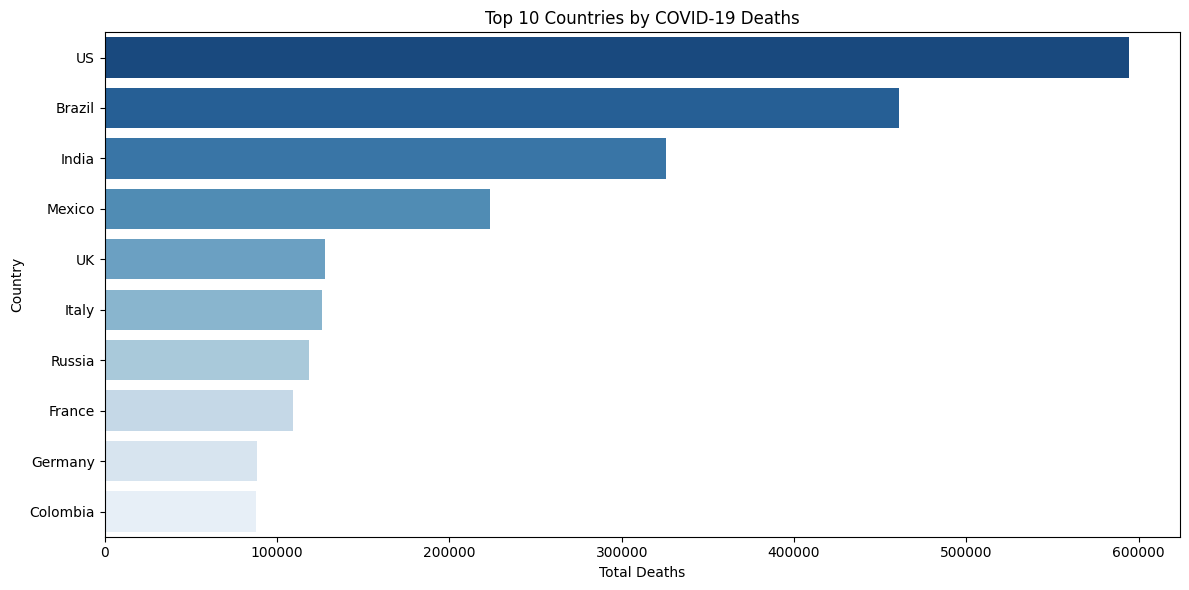

In [5]:
top_deaths = country_totals['Deaths'].nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_deaths.values, y=top_deaths.index, hue=top_deaths.index, legend=False, palette='Blues_r')
plt.title('Top 10 Countries by COVID-19 Deaths')
plt.xlabel('Total Deaths')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

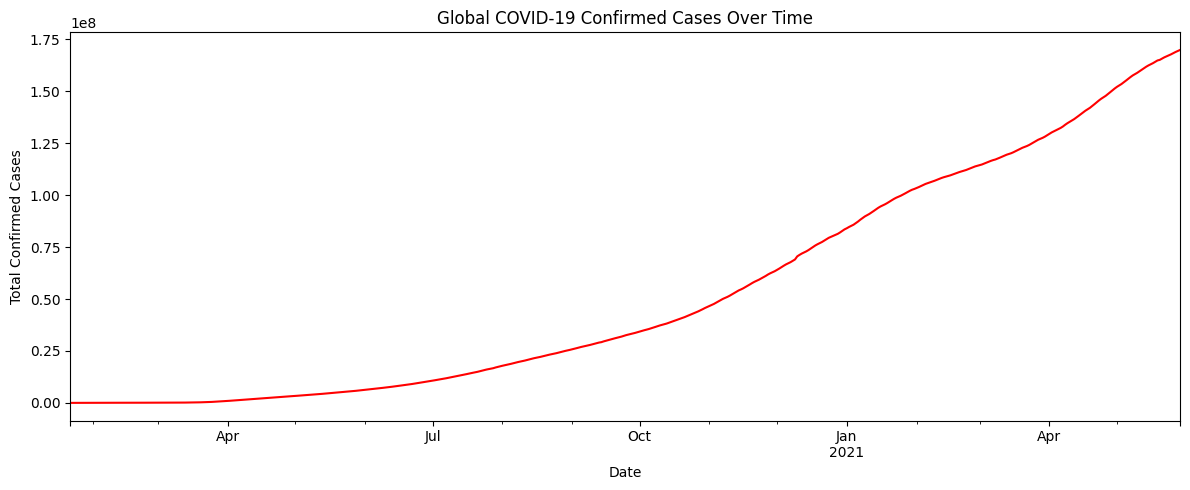

In [6]:
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])
global_trend = df.groupby('ObservationDate')['Confirmed'].sum()

plt.figure(figsize=(12,5))
global_trend.plot(color='red')
plt.title('Global COVID-19 Confirmed Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Total Confirmed Cases')
plt.tight_layout()
plt.show()

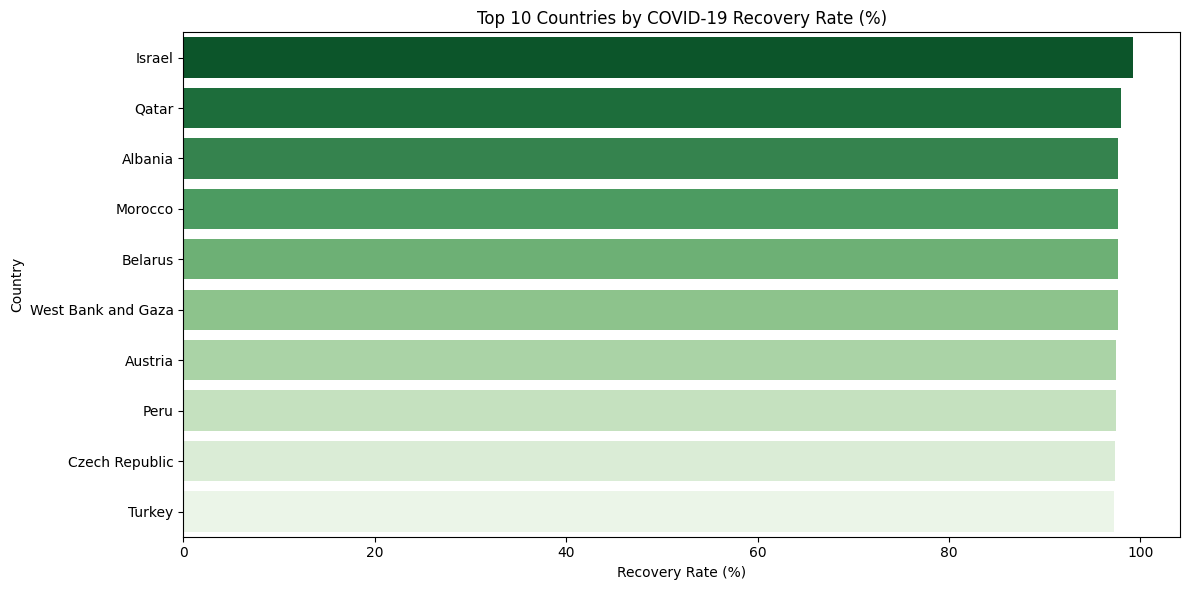

In [7]:
country_stats = country_totals.copy()
country_stats = country_stats[country_stats['Confirmed'] > 100000]
country_stats['Recovery_Rate'] = (country_stats['Recovered'] / country_stats['Confirmed'] * 100).round(2)
top_recovery = country_stats['Recovery_Rate'].sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_recovery.values, y=top_recovery.index, hue=top_recovery.index, legend=False, palette='Greens_r')
plt.title('Top 10 Countries by COVID-19 Recovery Rate (%)')
plt.xlabel('Recovery Rate (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## COVID-19 Global Data Analysis — Key Insights

1. The dataset covers 229 countries and regions from January 2020 to May 2021, with global confirmed cases reaching about 170 million

2. The US had the most confirmed cases (33.25 million), followed by India (27.89 million) and Brazil (16.47 million) — together nearly half of all global cases

3. The US also had the most deaths (594,306), followed by Brazil (461,057) and India (325,972)

4. Mexico ranked 4th in deaths (223,455) despite not being in the top 10 for confirmed cases, suggesting a much higher fatality rate

5. Global case growth sped up sharply from October 2020 onward, with another steep rise in spring 2021

6. Among countries with over 100,000 cases, Israel had the highest recovery rate (about 99%), and all top 10 countries were above 97%. Note: some countries, like the US, did not report recoveries consistently, so recovery rates should be compared carefully